In [55]:
import pandas as pd
import numpy as np
import time
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import mlxtend
from mlxtend.frequent_patterns import fpgrowth, association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder
import warnings
import IPython
from IPython.display import display, Markdown
import sys

print(f"python=={sys.version.split()[0]}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"networkx=={nx.__version__}")
print(f"mlxtend=={mlxtend.__version__}")
print(f"ipython=={IPython.__version__}")

# --- Setup & Optimization ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='mlxtend')
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

def optimize_types(df):
    for col in df.columns:
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
        elif df[col].dtype == 'float64': df[col] = df[col].astype('float32')
    return df

# --- Data Loading & Preprocessing ---
def load_and_prep_data():
    products = pd.read_csv('products.csv')
    aisles = pd.read_csv('aisles.csv')
    departments = pd.read_csv('departments.csv')
    order_products = pd.read_csv('order_products__prior.csv', nrows = 2e5)
    orders = pd.read_csv('orders.csv')[['order_id', 'order_dow', 'order_hour_of_day']]

    # Merging
    df = order_products.merge(products, on='product_id', how='left')
    df = df.merge(aisles, on='aisle_id', how='left')
    df = df.merge(departments, on='department_id', how='left')
    df = df.merge(orders, on='order_id', how='left')

    # Dimensional Engineering
    bins = [0, 6, 12, 18, 24]
    labels = ['Night', 'Morning', 'Afternoon', 'Evening']
    df['hour_bin'] = 'Hour_' + pd.cut(df['order_hour_of_day'], bins=bins, labels=labels, right=False).astype(str)
    df['day_type'] = df['order_dow'].apply(lambda x: 'Weekend' if x in [0, 1] else 'Weekday')
    
    basket_counts = df.groupby('order_id')['product_id'].transform('count')
    df['basket_size'] = pd.cut(basket_counts, bins=[0, 5, 15, 100], labels=['Small_Basket', 'Medium_Basket', 'Large_Basket'])
    
    return optimize_types(df)

# --- Core Mining Utilities ---
def get_basket(df, level_column):
    """Prepares sparse TransactionEncoder dataframe."""
    df = df.dropna(subset=[level_column, 'hour_bin', 'day_type', 'basket_size'])
    baskets = df.groupby('order_id')[level_column].unique().reset_index()
    meta = df.drop_duplicates('order_id')[['order_id', 'hour_bin', 'day_type', 'basket_size']]
    merged = baskets.merge(meta, on='order_id')
    
    transaction_list = [list(items) + list(meta) for items, meta in zip(merged[level_column], merged[['hour_bin', 'day_type', 'basket_size']].values)]
    
    te = TransactionEncoder()
    te_ary = te.fit(transaction_list).transform(transaction_list, sparse=True)
    return pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

def enhance_rules(rules_df, level_type):
    """Calculates Kulc/IR and applies your specific level thresholds."""
    if rules_df.empty: return rules_df
    
    # Formulas: Kulczynski & Imbalance Ratio
    rules_df['kulczynski'] = (rules_df['support']/rules_df['antecedent support'] + rules_df['support']/rules_df['consequent support']) / 2
    rules_df['ir'] = np.abs(rules_df['antecedent support'] - rules_df['consequent support']) / (rules_df['antecedent support'] + rules_df['consequent support'] - rules_df['support'])
    
    # Threshold Logic
    if level_type == 'product_name':
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.3) & (rules_df['ir'] < 0.7)
    else: # Aisle or Department
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.5) & (rules_df['ir'] < 0.5)
    
    rules_df['ant_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_df['cons_str'] = rules_df['consequents'].apply(lambda x: ', '.join(list(x)))
    return rules_df

def filter_redundancy(low_rules, high_rules, mapping):
    if low_rules.empty or high_rules is None or high_rules.empty: return low_rules
    
    high_set = set((tuple(sorted(list(a))), tuple(sorted(list(c)))) for a, c in zip(high_rules['antecedents'], high_rules['consequents']))

    def check_redundancy(row):
        ant_high = tuple(sorted(set(mapping.get(item, item) for item in row['antecedents'])))
        cons_high = tuple(sorted(set(mapping.get(item, item) for item in row['consequents'])))
        return (ant_high, cons_high) in high_set

    return low_rules[~low_rules.apply(check_redundancy, axis=1)]

# --- Visualization ---
def plot_robustness(rules_df, title):
    if rules_df.empty: return
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=rules_df, x='kulczynski', y='ir', size='lift', hue='is_robust', palette={True: 'green', False: 'red'}, alpha=0.6)
    plt.title(f"Robustness: {title}")
    plt.axvline(0.5, color='gray', linestyle='--')
    plt.show()

# --- Master Pipeline ---
def run_master_analysis(df):
    mapping_data = df[['product_name', 'aisle', 'department']].drop_duplicates()
    prod_to_aisle = mapping_data.set_index('product_name')['aisle'].to_dict()
    aisle_to_dept = mapping_data[['aisle', 'department']].drop_duplicates().set_index('aisle')['department'].to_dict()

    level_configs = [
        ('department', 0.1, None),
        ('aisle', 0.02, aisle_to_dept),
        ('product_name', 0.005, prod_to_aisle)
    ]
    
    results = {}
    performance_log = []

    for dim in ['Weekend', 'Weekday']:
        print(f"\n" + "█" * 60)
        print(f"  DIMENSION: {dim.upper()}")
        print("█" * 60)
        
        df_subset = df[df['day_type'] == dim]
        prev_rules = None
        
        for level, sup, mapping in level_configs:
            basket_df = get_basket(df_subset, level)
            
            apriori_time = None
            if level == 'department':
                start_apri = time.time()
                _ = apriori(basket_df, min_support=sup, use_colnames=True)
                apriori_time = time.time() - start_apri
            
            start_fp = time.time()
            freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
            fp_time = time.time() - start_fp
            
            freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
            rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
            
            rules = enhance_rules(rules, level)
            filtered_rules = filter_redundancy(rules, prev_rules, mapping)
            robust_count = filtered_rules['is_robust'].sum()
            print(f"\n--- LEVEL: {level.upper()} (Sup: {sup}) ---")
            print(f"Found: {len(rules):<6} | Unique: {len(filtered_rules):<6} | Robust: {robust_count}")
            
            if apriori_time:
                print(f"Performance | Apriori: {apriori_time:.2f}s | FP-Growth: {fp_time:.2f}s")
                print(f"FP-Growth is {apriori_time/fp_time:.1f}x faster")
            else:
                print(f"Performance | FP-Growth: {fp_time:.2f}s")
            
            if not filtered_rules.empty:
                plot_robustness(filtered_rules, f"{dim} - {level}")
                top = filtered_rules[filtered_rules['is_robust']].sort_values('lift', ascending=False)
                
                if not top.empty:
                    print(f"\n>>> Robust Rules (Sorted by Lift):")
                    with pd.option_context('display.max_colwidth', 60, 'display.width', 250):
                        print(top[['ant_str', 'cons_str', 'lift', 'kulczynski']].to_string(index=False))
            
            results[(dim, level)] = filtered_rules
            prev_rules = rules
            print("-" * 40)
    
    return results

python==3.11.9
pandas==3.0.1
numpy==1.26.4
matplotlib==3.10.8
seaborn==0.13.2
networkx==3.4.2
mlxtend==0.24.0
ipython==9.3.0


In [56]:
def plot_rules_network(rules_df, title="Association Rules Network", num_rules=100):
    if rules_df.empty:
        print(f"No rules to plot for: {title}")
        return

    G = nx.DiGraph()
    top_rules = rules_df.sort_values('lift', ascending=False).head(num_rules)
    
    for _, row in top_rules.iterrows():
        ant = row['ant_str']
        cons = row['cons_str']
        G.add_edge(ant, cons, weight=row['lift'], supp=row['support'])

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=1, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="#a8dadc", alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * 0.5 for u, v in edges]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='#457b9d', 
                           arrowsize=15, connectionstyle='arc3,rad=0.1')

    plt.title(f"{title}\n(Line thickness = Lift)", fontsize=14)
    plt.axis('off')
    plt.show()

In [57]:
def run_level_pipeline(df_subset, level, sup, mapping, prev_rules, dim_name):
    basket_df = get_basket(df_subset, level)
    freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
    rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
    rules = enhance_rules(rules, level)
    filtered_rules = filter_redundancy(rules, prev_rules, mapping)
    
    display(Markdown(f"## {dim_name} - {level.upper()} Analysis"))
    print(f"Found: {len(rules)} | Unique: {len(filtered_rules)} | Robust: {filtered_rules['is_robust'].sum()}")
    
    if not filtered_rules.empty:
        plot_robustness(filtered_rules, f"{dim_name} - {level}")
        top = filtered_rules[filtered_rules['is_robust']].sort_values('lift', ascending=False)
        if not top.empty:
            display(Markdown(f"### Top Robust Rules"))
            display(top[['ant_str', 'cons_str', 'lift', 'kulczynski', 'ir']].head(25))
            plot_rules_network(top, title=f"Network: {dim_name} {level}")
            
    return rules

## main code


████████████████████████████████████████████████████████████
  DIMENSION: WEEKEND
████████████████████████████████████████████████████████████

--- LEVEL: DEPARTMENT (Sup: 0.1) ---
Found: 3714   | Unique: 3714   | Robust: 272
Performance | Apriori: 0.14s | FP-Growth: 0.10s
FP-Growth is 1.4x faster


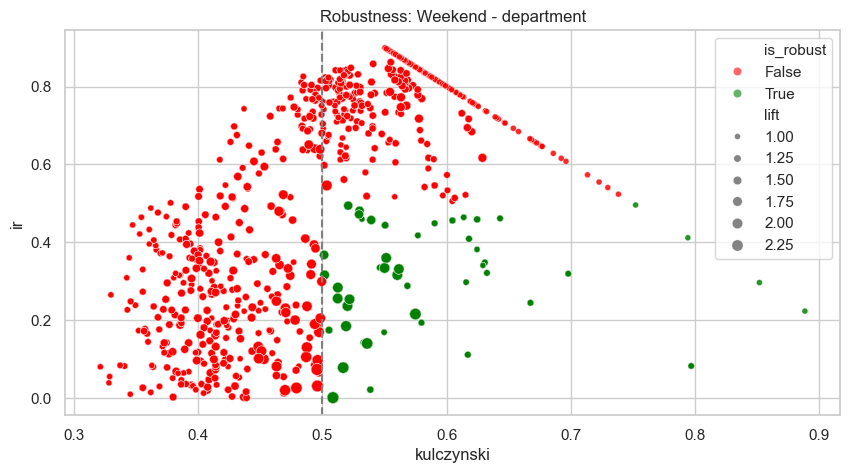


>>> Robust Rules (Sorted by Lift):
                                   ant_str                                   cons_str     lift  kulczynski
                              Large_Basket       produce, dairy eggs, Weekend, bakery 2.363184    0.508429
                              Large_Basket                produce, dairy eggs, bakery 2.363184    0.508429
                     Weekend, Large_Basket                produce, dairy eggs, bakery 2.363184    0.508429
               produce, dairy eggs, bakery                               Large_Basket 2.363184    0.508429
      produce, dairy eggs, Weekend, bakery                               Large_Basket 2.363184    0.508429
               produce, dairy eggs, bakery                      Weekend, Large_Basket 2.363184    0.508429
                              Large_Basket       produce, dairy eggs, Weekend, pantry 2.264080    0.516669
                     Weekend, Large_Basket                produce, dairy eggs, pantry 2.264080    0.516669
 

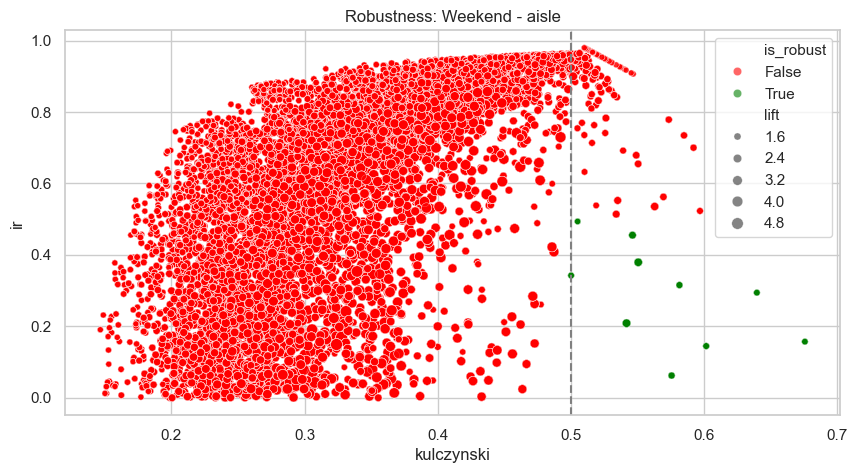


>>> Robust Rules (Sorted by Lift):
                                              ant_str                                              cons_str     lift  kulczynski
                           Large_Basket, fresh fruits packaged vegetables fruits, fresh vegetables, Weekend 2.399705    0.541700
         packaged vegetables fruits, fresh vegetables                   Weekend, Large_Basket, fresh fruits 2.399705    0.541700
                  Weekend, Large_Basket, fresh fruits          packaged vegetables fruits, fresh vegetables 2.399705    0.541700
packaged vegetables fruits, fresh vegetables, Weekend                            Large_Basket, fresh fruits 2.399705    0.541700
         packaged vegetables fruits, fresh vegetables                            Large_Basket, fresh fruits 2.399705    0.541700
                           Large_Basket, fresh fruits          packaged vegetables fruits, fresh vegetables 2.399705    0.541700
                       fresh vegetables, Large_Basket     Wee

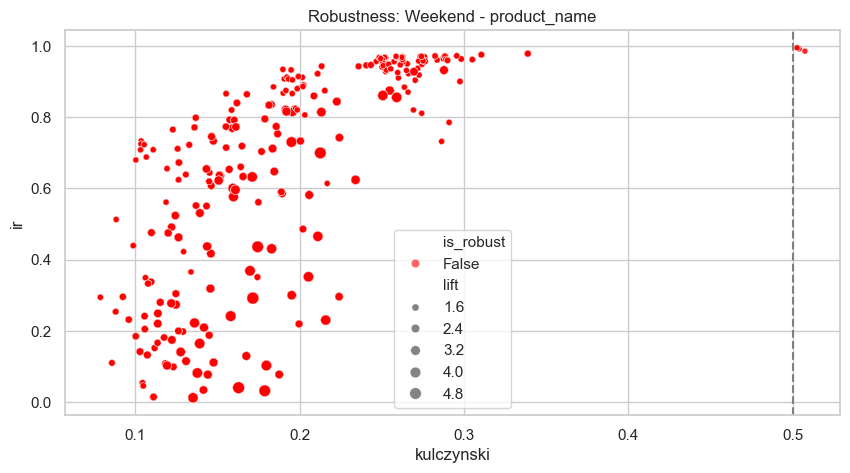

----------------------------------------

████████████████████████████████████████████████████████████
  DIMENSION: WEEKDAY
████████████████████████████████████████████████████████████

--- LEVEL: DEPARTMENT (Sup: 0.1) ---
Found: 3010   | Unique: 3010   | Robust: 228
Performance | Apriori: 0.20s | FP-Growth: 0.14s
FP-Growth is 1.5x faster


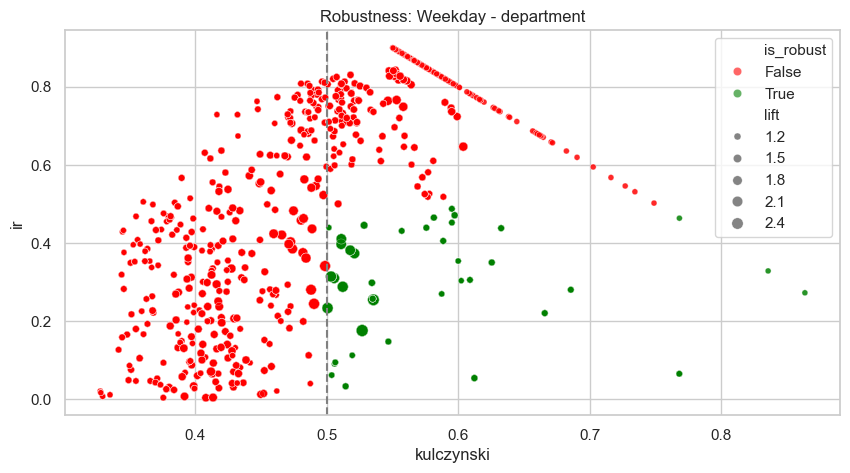


>>> Robust Rules (Sorted by Lift):
                                ant_str                                cons_str     lift  kulczynski
                  Weekday, Large_Basket             produce, frozen, dairy eggs 2.563941    0.526857
   dairy eggs, frozen, Weekday, produce                            Large_Basket 2.563941    0.526857
                           Large_Basket    dairy eggs, frozen, Weekday, produce 2.563941    0.526857
            produce, frozen, dairy eggs                            Large_Basket 2.563941    0.526857
            produce, frozen, dairy eggs                   Weekday, Large_Basket 2.563941    0.526857
                           Large_Basket             produce, frozen, dairy eggs 2.563941    0.526857
   dairy eggs, Weekday, produce, snacks                            Large_Basket 2.430410    0.535433
            produce, dairy eggs, snacks                            Large_Basket 2.430410    0.535433
            produce, dairy eggs, snacks                

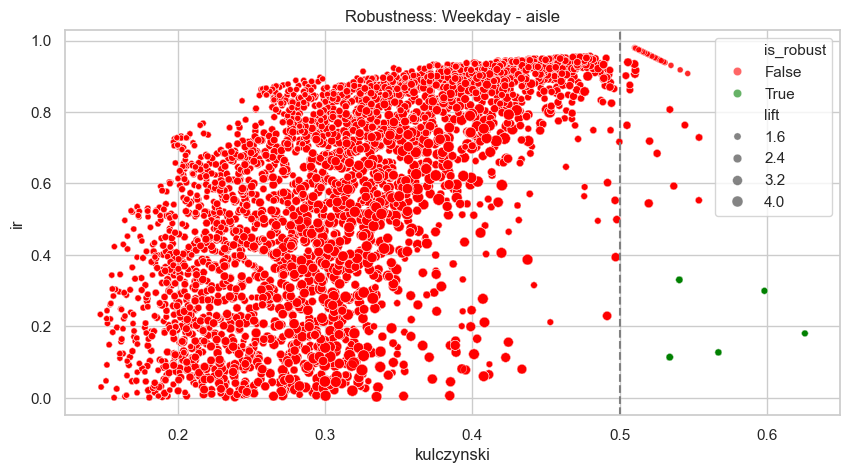


>>> Robust Rules (Sorted by Lift):
                                          ant_str                                          cons_str     lift  kulczynski
                   fresh vegetables, fresh fruits                        packaged vegetables fruits 1.663361    0.533914
                       packaged vegetables fruits           Weekday, fresh vegetables, fresh fruits 1.663361    0.533914
          Weekday, fresh vegetables, fresh fruits                        packaged vegetables fruits 1.663361    0.533914
                       packaged vegetables fruits                    fresh vegetables, fresh fruits 1.663361    0.533914
                   fresh vegetables, fresh fruits               packaged vegetables fruits, Weekday 1.663361    0.533914
              packaged vegetables fruits, Weekday                    fresh vegetables, fresh fruits 1.663361    0.533914
                                 fresh vegetables packaged vegetables fruits, Weekday, fresh fruits 1.612013    0.540

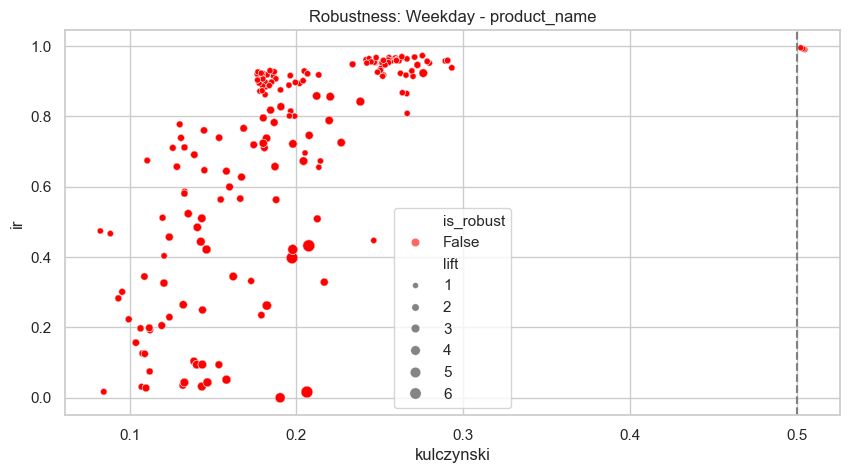

----------------------------------------


{('Weekend',
  'department'):                                     antecedents  \
 0                    frozenset({Medium_Basket})   
 1                          frozenset({Weekend})   
 2                          frozenset({produce})   
 3                    frozenset({Medium_Basket})   
 4                       frozenset({dairy eggs})   
 ...                                         ...   
 3709  frozenset({Large_Basket, Hour_Afternoon})   
 3710       frozenset({Weekend, Hour_Afternoon})   
 3711                  frozenset({Large_Basket})   
 3712                       frozenset({Weekend})   
 3713                frozenset({Hour_Afternoon})   
 
                                     consequents  antecedent support  \
 0                          frozenset({Weekend})            0.504280   
 1                    frozenset({Medium_Basket})            1.000000   
 2                    frozenset({Medium_Basket})            0.776875   
 3                          frozenset({produce})         

In [58]:

df_merged = load_and_prep_data()
run_master_analysis(df_merged)

In [59]:
mapping_data = df_merged[['product_name', 'aisle', 'department']].drop_duplicates()
prod_to_aisle = mapping_data.set_index('product_name')['aisle'].to_dict()
aisle_to_dept = mapping_data[['aisle', 'department']].drop_duplicates().set_index('aisle')['department'].to_dict()
rules_store = {'Weekend': {}, 'Weekday': {}}

## Weekend - DEPARTMENT Analysis

Found: 3714 | Unique: 3714 | Robust: 272


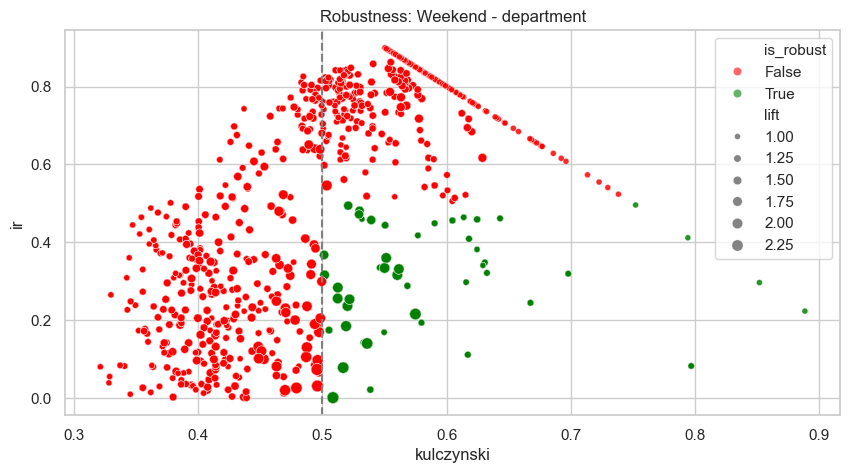

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
3394,Large_Basket,"produce, dairy eggs, Weekend, bakery",2.363184,0.508429,0.000904
3367,Large_Basket,"produce, dairy eggs, bakery",2.363184,0.508429,0.000904
3389,"Weekend, Large_Basket","produce, dairy eggs, bakery",2.363184,0.508429,0.000904
3354,"produce, dairy eggs, bakery",Large_Basket,2.363184,0.508429,0.000904
3371,"produce, dairy eggs, Weekend, bakery",Large_Basket,2.363184,0.508429,0.000904
3376,"produce, dairy eggs, bakery","Weekend, Large_Basket",2.363184,0.508429,0.000904
3690,Large_Basket,"produce, dairy eggs, Weekend, pantry",2.264080,0.516669,0.077911
3685,"Weekend, Large_Basket","produce, dairy eggs, pantry",2.264080,0.516669,0.077911
3672,"produce, dairy eggs, pantry","Weekend, Large_Basket",2.264080,0.516669,0.077911
3667,"produce, dairy eggs, Weekend, pantry",Large_Basket,2.264080,0.516669,0.077911


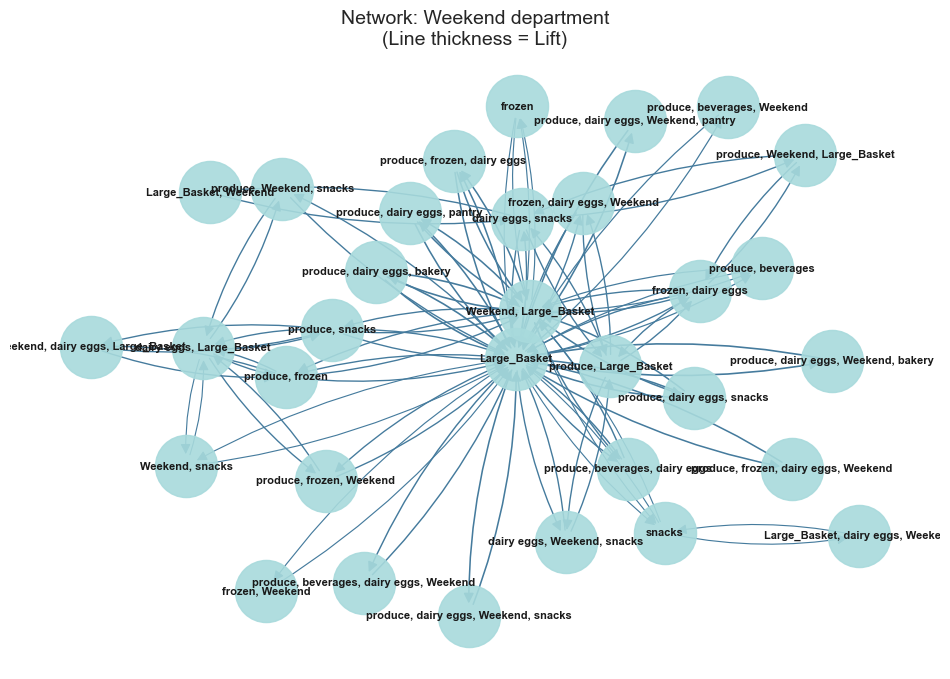

## Weekday - DEPARTMENT Analysis

Found: 3010 | Unique: 3010 | Robust: 228


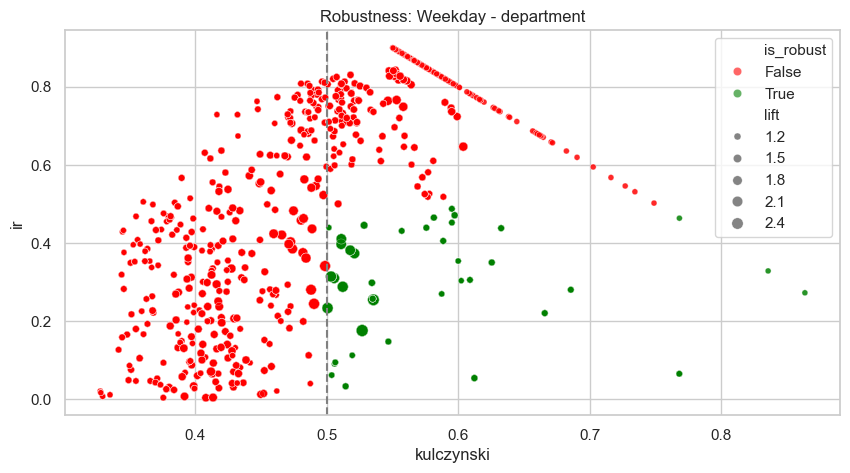

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
2389,"Weekday, Large_Basket","produce, frozen, dairy eggs",2.563941,0.526857,0.175621
2372,"dairy eggs, frozen, Weekday, produce",Large_Basket,2.563941,0.526857,0.175621
2397,Large_Basket,"dairy eggs, frozen, Weekday, produce",2.563941,0.526857,0.175621
2356,"produce, frozen, dairy eggs",Large_Basket,2.563941,0.526857,0.175621
2380,"produce, frozen, dairy eggs","Weekday, Large_Basket",2.563941,0.526857,0.175621
2369,Large_Basket,"produce, frozen, dairy eggs",2.563941,0.526857,0.175621
2147,"dairy eggs, Weekday, produce, snacks",Large_Basket,2.430410,0.535433,0.254309
2131,"produce, dairy eggs, snacks",Large_Basket,2.430410,0.535433,0.254309
2158,"produce, dairy eggs, snacks","Weekday, Large_Basket",2.430410,0.535433,0.254309
2159,"Weekday, Large_Basket","produce, dairy eggs, snacks",2.430410,0.535433,0.254309


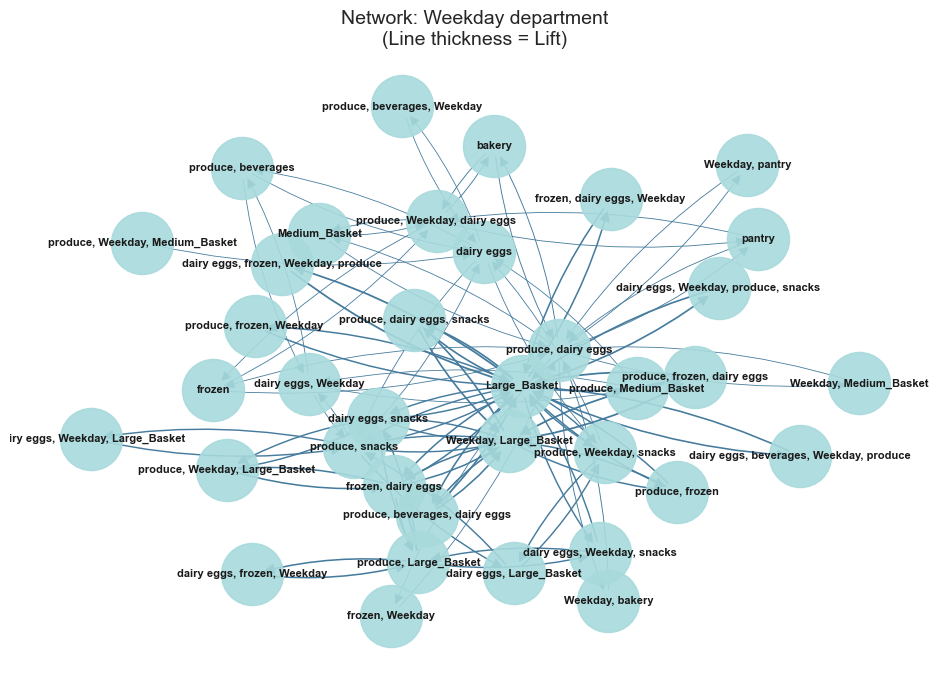

In [60]:
for dim in ['Weekend', 'Weekday']:
    df_subset = df_merged[df_merged['day_type'] == dim]
    rules_store[dim]['department'] = run_level_pipeline(
        df_subset, 
        level='department', 
        sup=0.1, 
        mapping=None,
        prev_rules=None,
        dim_name=dim
    )

## Weekend - AISLE Analysis

Found: 65718 | Unique: 40058 | Robust: 60


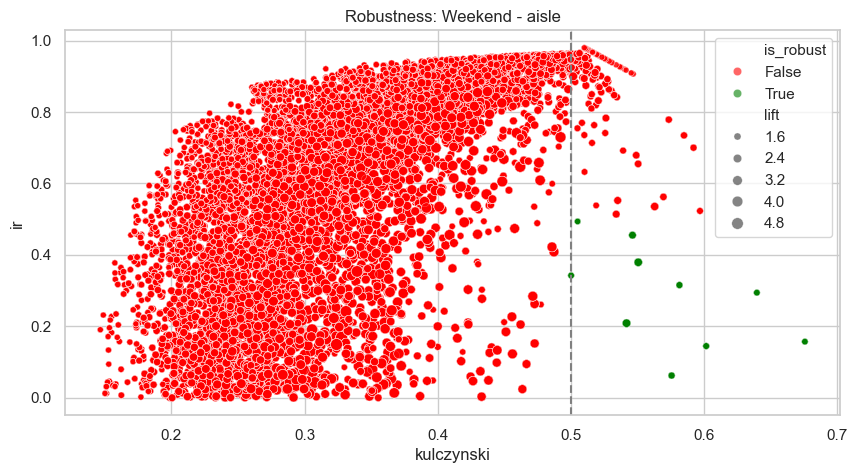

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
48535,"Large_Basket, fresh fruits","packaged vegetables fruits, fresh vegetables, ...",2.399705,0.541700,0.208825
48533,"packaged vegetables fruits, fresh vegetables","Weekend, Large_Basket, fresh fruits",2.399705,0.541700,0.208825
48528,"Weekend, Large_Basket, fresh fruits","packaged vegetables fruits, fresh vegetables",2.399705,0.541700,0.208825
48526,"packaged vegetables fruits, fresh vegetables, ...","Large_Basket, fresh fruits",2.399705,0.541700,0.208825
48509,"packaged vegetables fruits, fresh vegetables","Large_Basket, fresh fruits",2.399705,0.541700,0.208825
48508,"Large_Basket, fresh fruits","packaged vegetables fruits, fresh vegetables",2.399705,0.541700,0.208825
48538,"fresh vegetables, Large_Basket","Weekend, packaged vegetables fruits, fresh fruits",2.334360,0.550486,0.379325
48530,"Weekend, fresh vegetables, Large_Basket","packaged vegetables fruits, fresh fruits",2.334360,0.550486,0.379325
48511,"fresh vegetables, Large_Basket","packaged vegetables fruits, fresh fruits",2.334360,0.550486,0.379325
48531,"packaged vegetables fruits, fresh fruits","Weekend, fresh vegetables, Large_Basket",2.334360,0.550486,0.379325


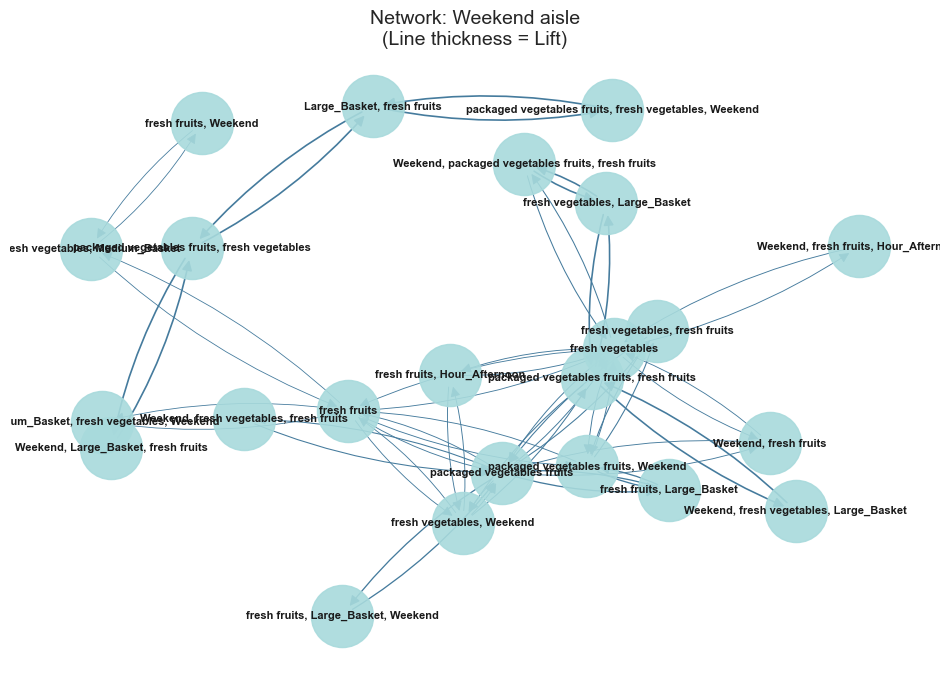

## Weekday - AISLE Analysis

Found: 33796 | Unique: 19608 | Robust: 30


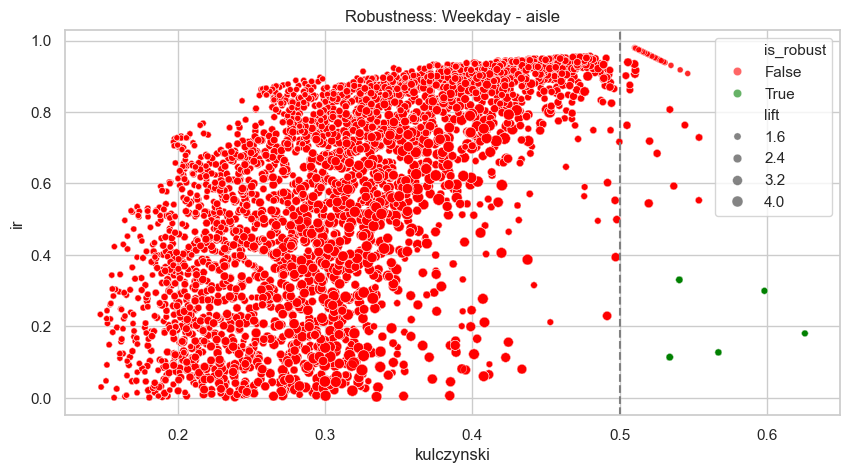

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
156,"fresh vegetables, fresh fruits",packaged vegetables fruits,1.663361,0.533914,0.113856
170,packaged vegetables fruits,"Weekday, fresh vegetables, fresh fruits",1.663361,0.533914,0.113856
163,"Weekday, fresh vegetables, fresh fruits",packaged vegetables fruits,1.663361,0.533914,0.113856
157,packaged vegetables fruits,"fresh vegetables, fresh fruits",1.663361,0.533914,0.113856
168,"fresh vegetables, fresh fruits","packaged vegetables fruits, Weekday",1.663361,0.533914,0.113856
165,"packaged vegetables fruits, Weekday","fresh vegetables, fresh fruits",1.663361,0.533914,0.113856
171,fresh vegetables,"packaged vegetables fruits, Weekday, fresh fruits",1.612013,0.540448,0.330403
166,"packaged vegetables fruits, fresh fruits","Weekday, fresh vegetables",1.612013,0.540448,0.330403
155,"packaged vegetables fruits, fresh fruits",fresh vegetables,1.612013,0.540448,0.330403
167,"Weekday, fresh vegetables","packaged vegetables fruits, fresh fruits",1.612013,0.540448,0.330403


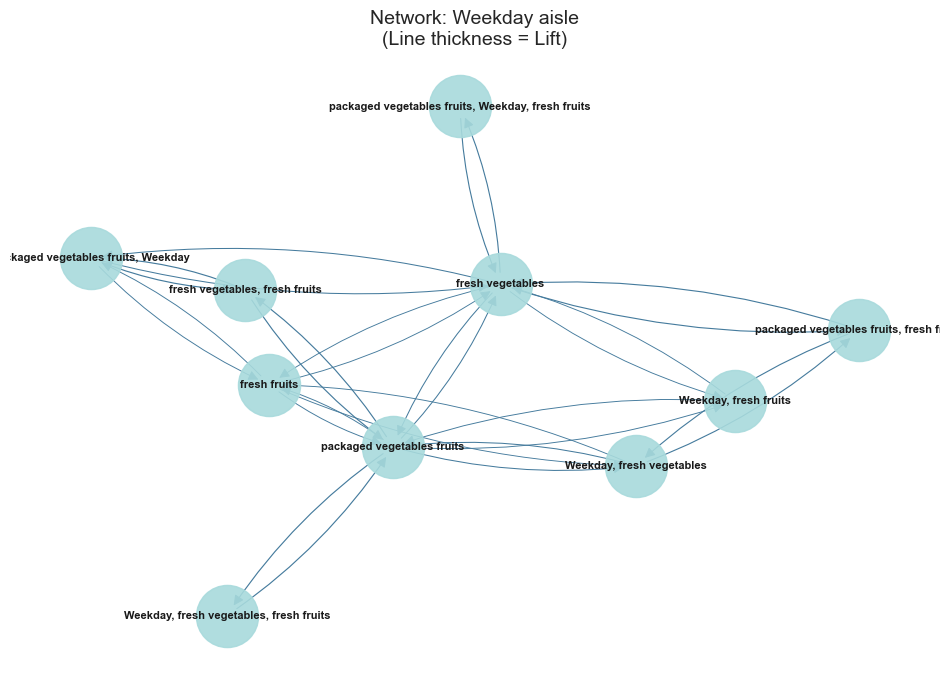

In [61]:
for dim in ['Weekend', 'Weekday']:
    df_subset = df_merged[df_merged['day_type'] == dim]
    rules_store[dim]['aisle'] = run_level_pipeline(
        df_subset, 
        level='aisle', 
        sup=0.02, 
        mapping=aisle_to_dept,
        prev_rules=rules_store[dim]['department'],
        dim_name=dim
    )

## Weekend - PRODUCT_NAME Analysis

Found: 7642 | Unique: 1424 | Robust: 0


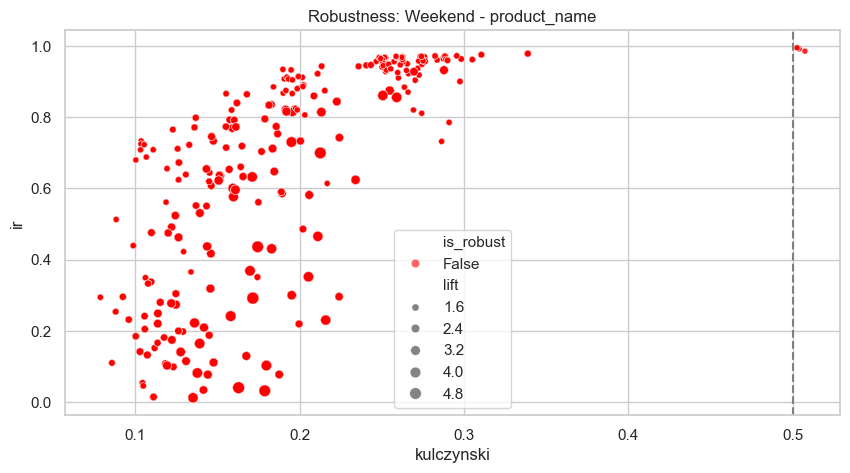

## Weekday - PRODUCT_NAME Analysis

Found: 5014 | Unique: 1044 | Robust: 0


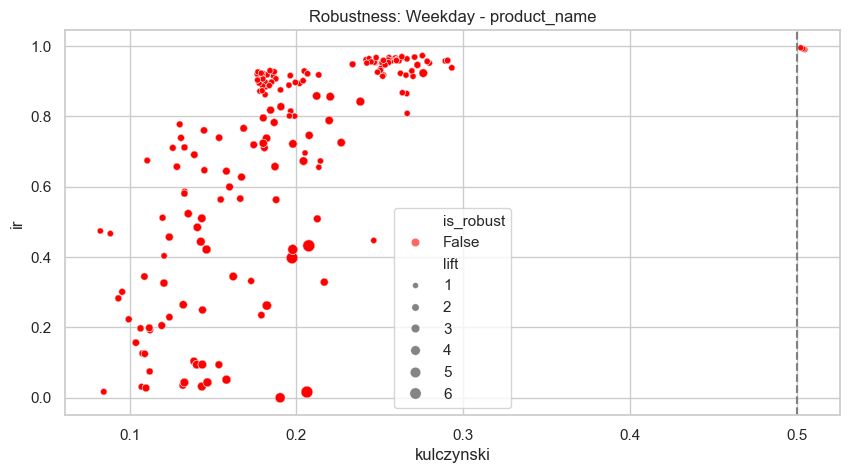

In [62]:
for dim in ['Weekend', 'Weekday']:
    df_subset = df_merged[df_merged['day_type'] == dim]
    rules_store[dim]['product_name'] = run_level_pipeline(
        df_subset,
        level='product_name',
        sup=0.005,
        mapping=prod_to_aisle,
        prev_rules=rules_store[dim]['aisle'],
        dim_name=dim
    )

In [63]:
for bin_name in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
    rules_store[bin_name] = {}

## Hour_Morning - DEPARTMENT Analysis

Found: 3848 | Unique: 3848 | Robust: 314


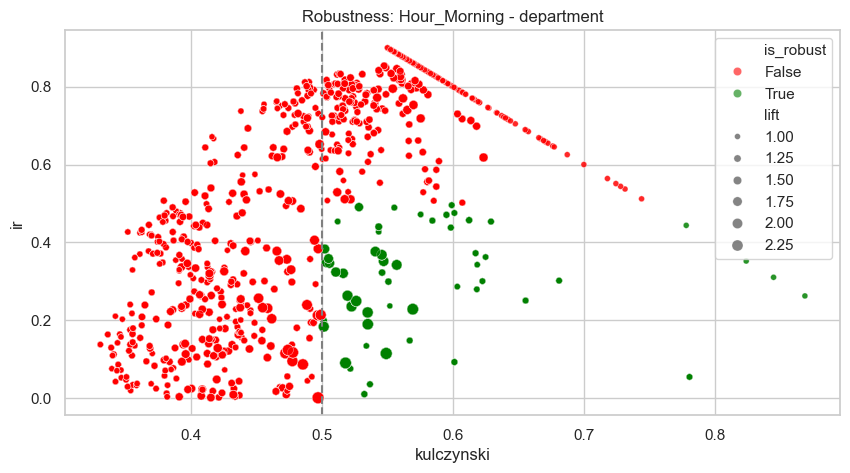

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
3646,"produce, frozen, dairy eggs",Large_Basket,2.494701,0.549183,0.115166
3687,Large_Basket,"produce, frozen, dairy eggs, Hour_Morning",2.494701,0.549183,0.115166
3659,Large_Basket,"produce, frozen, dairy eggs",2.494701,0.549183,0.115166
3679,"Large_Basket, Hour_Morning","produce, frozen, dairy eggs",2.494701,0.549183,0.115166
3662,"produce, frozen, dairy eggs, Hour_Morning",Large_Basket,2.494701,0.549183,0.115166
3670,"produce, frozen, dairy eggs","Large_Basket, Hour_Morning",2.494701,0.549183,0.115166
3748,Large_Basket,"produce, dairy eggs, pantry",2.395812,0.518141,0.090780
3737,"produce, dairy eggs, pantry",Large_Basket,2.395812,0.518141,0.090780
3777,Large_Basket,"produce, dairy eggs, Hour_Morning, pantry",2.395812,0.518141,0.090780
3752,"produce, dairy eggs, Hour_Morning, pantry",Large_Basket,2.395812,0.518141,0.090780


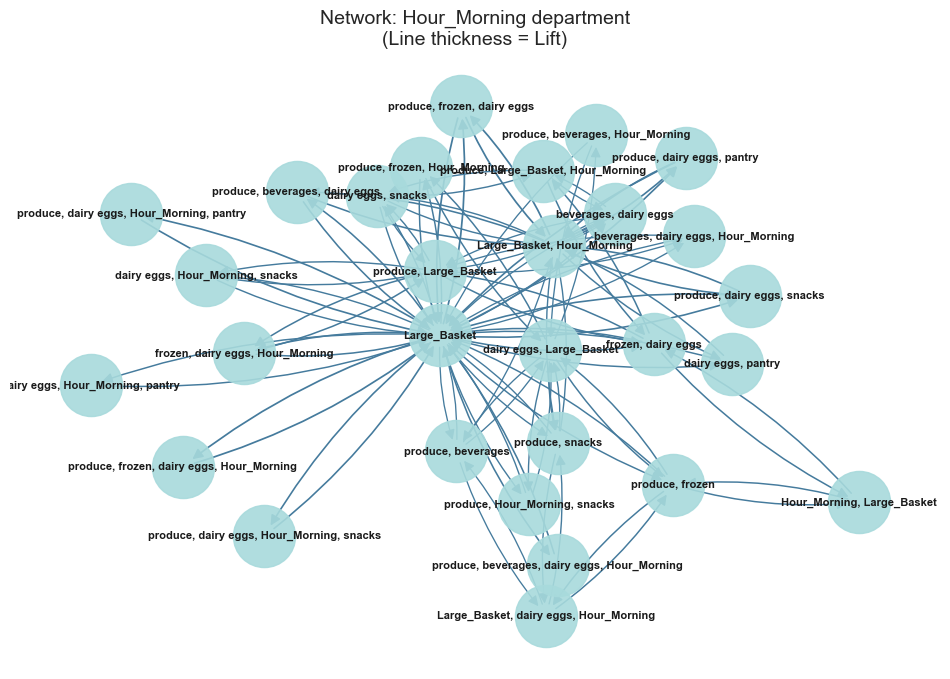

## Hour_Afternoon - DEPARTMENT Analysis

Found: 3776 | Unique: 3776 | Robust: 262


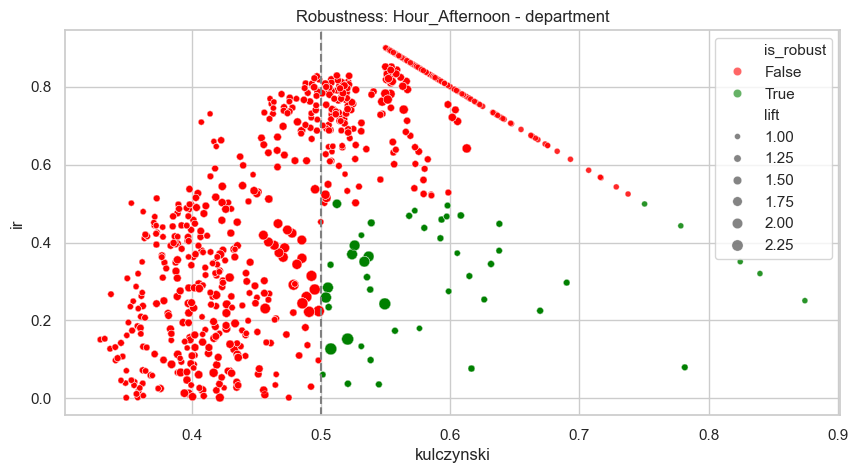

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
2750,"produce, frozen, dairy eggs","Large_Basket, Hour_Afternoon",2.439202,0.520676,0.152240
2728,"produce, frozen, dairy eggs",Large_Basket,2.439202,0.520676,0.152240
2745,"produce, frozen, dairy eggs, Hour_Afternoon",Large_Basket,2.439202,0.520676,0.152240
2741,Large_Basket,"produce, frozen, dairy eggs",2.439202,0.520676,0.152240
2768,Large_Basket,"produce, frozen, dairy eggs, Hour_Afternoon",2.439202,0.520676,0.152240
2763,"Large_Basket, Hour_Afternoon","produce, frozen, dairy eggs",2.439202,0.520676,0.152240
2582,Large_Basket,"produce, dairy eggs, pantry",2.426742,0.507645,0.126919
2610,Large_Basket,"produce, dairy eggs, Hour_Afternoon, pantry",2.426742,0.507645,0.126919
2605,"Large_Basket, Hour_Afternoon","produce, dairy eggs, pantry",2.426742,0.507645,0.126919
2592,"produce, dairy eggs, pantry","Large_Basket, Hour_Afternoon",2.426742,0.507645,0.126919


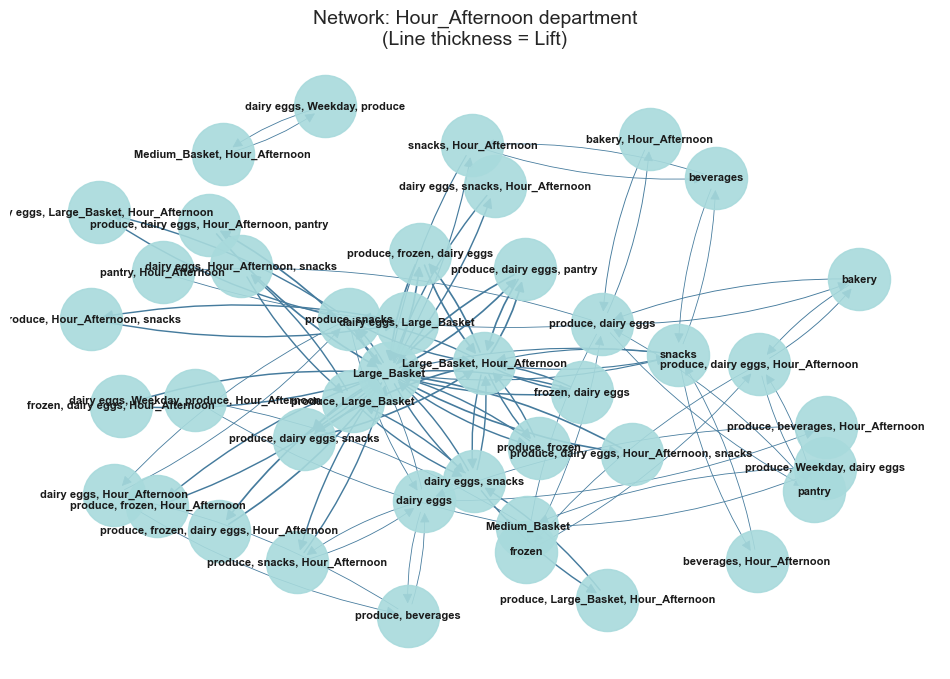

## Hour_Evening - DEPARTMENT Analysis

Found: 4472 | Unique: 4472 | Robust: 328


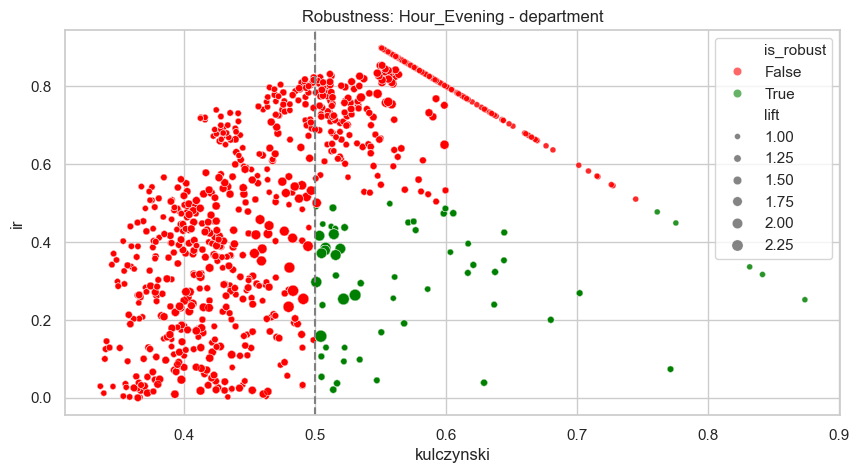

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
4211,Large_Basket,"produce, dairy eggs, Hour_Evening, pantry",2.452804,0.504354,0.158088
4200,"Hour_Evening, Large_Basket","produce, dairy eggs, pantry",2.452804,0.504354,0.158088
4197,"produce, dairy eggs, pantry","Hour_Evening, Large_Basket",2.452804,0.504354,0.158088
4186,"produce, dairy eggs, Hour_Evening, pantry",Large_Basket,2.452804,0.504354,0.158088
4171,"produce, dairy eggs, pantry",Large_Basket,2.452804,0.504354,0.158088
4182,Large_Basket,"produce, dairy eggs, pantry",2.452804,0.504354,0.158088
3924,"produce, frozen, dairy eggs","Hour_Evening, Large_Basket",2.352755,0.530556,0.263736
3916,"produce, frozen, dairy eggs, Hour_Evening",Large_Basket,2.352755,0.530556,0.263736
3900,"produce, frozen, dairy eggs",Large_Basket,2.352755,0.530556,0.263736
3941,Large_Basket,"produce, frozen, dairy eggs, Hour_Evening",2.352755,0.530556,0.263736


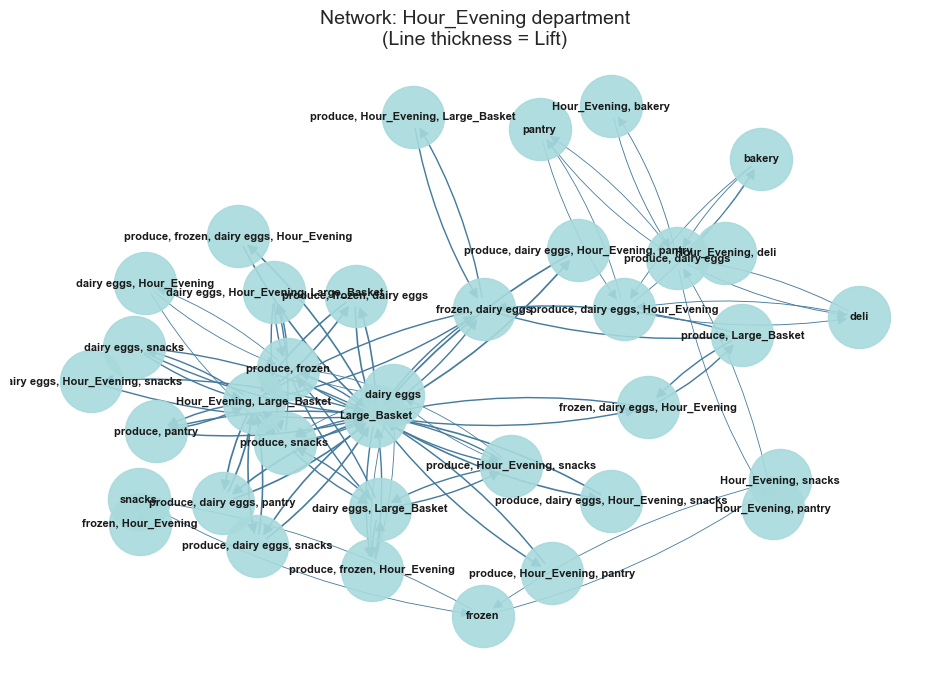

## Hour_Night - DEPARTMENT Analysis

Found: 2920 | Unique: 2920 | Robust: 232


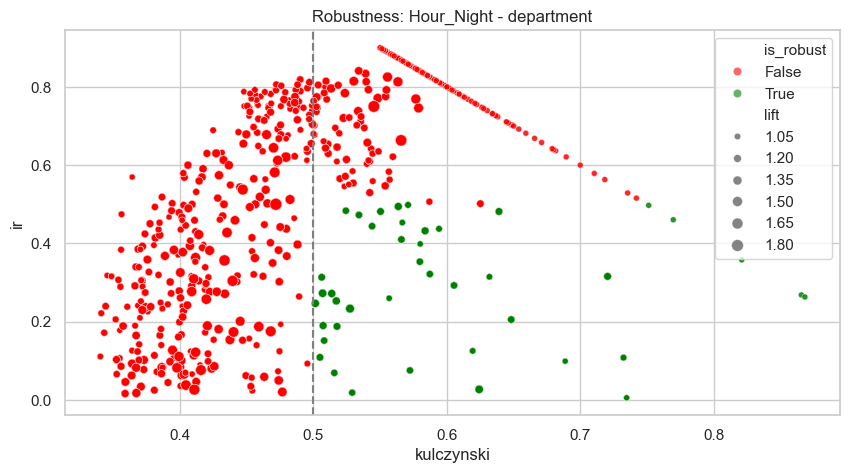

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
891,pantry,"dairy eggs, Weekday",1.314179,0.527401,0.233480
886,"dairy eggs, Weekday",pantry,1.314179,0.527401,0.233480
907,"Hour_Night, pantry","dairy eggs, Weekday",1.314179,0.527401,0.233480
902,"dairy eggs, Weekday","Hour_Night, pantry",1.314179,0.527401,0.233480
898,"dairy eggs, Weekday, Hour_Night",pantry,1.314179,0.527401,0.233480
911,pantry,"dairy eggs, Weekday, Hour_Night",1.314179,0.527401,0.233480
756,"produce, dairy eggs","Hour_Night, Medium_Basket",1.265081,0.624218,0.027132
762,Medium_Basket,"produce, Hour_Night, dairy eggs",1.265081,0.624218,0.027132
751,"produce, Hour_Night, dairy eggs",Medium_Basket,1.265081,0.624218,0.027132
749,Medium_Basket,"produce, dairy eggs",1.265081,0.624218,0.027132


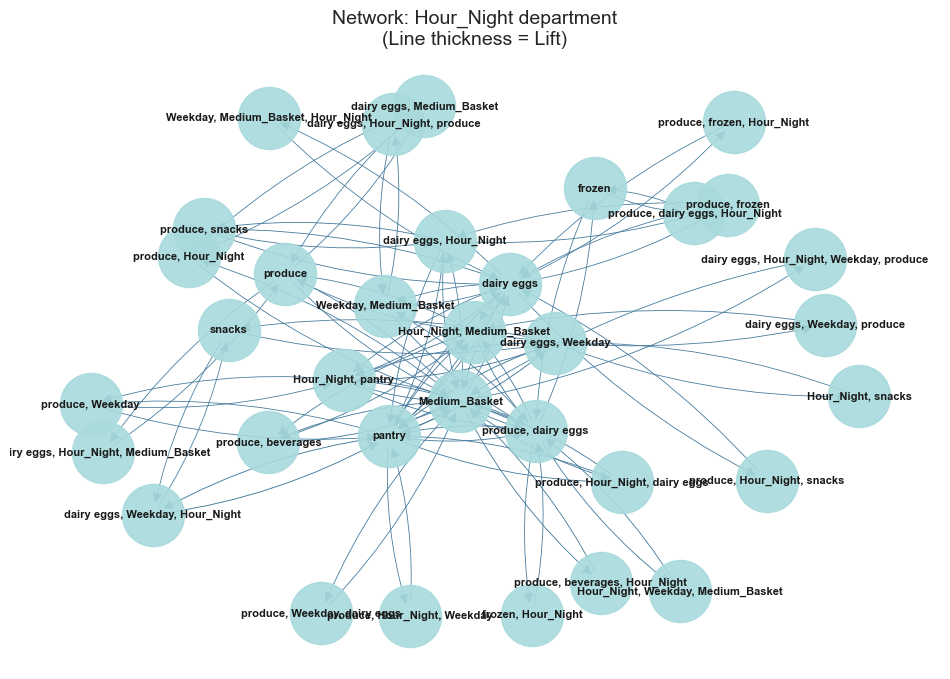

In [64]:
for bin_name in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
    df_subset = df_merged[df_merged['hour_bin'] == bin_name]
    rules_store[bin_name]['department'] = run_level_pipeline(
        df_subset, 
        level='department', 
        sup=0.1, 
        mapping=None,
        prev_rules=None,
        dim_name=bin_name
    )

## Hour_Morning - AISLE Analysis

Found: 58952 | Unique: 33682 | Robust: 54


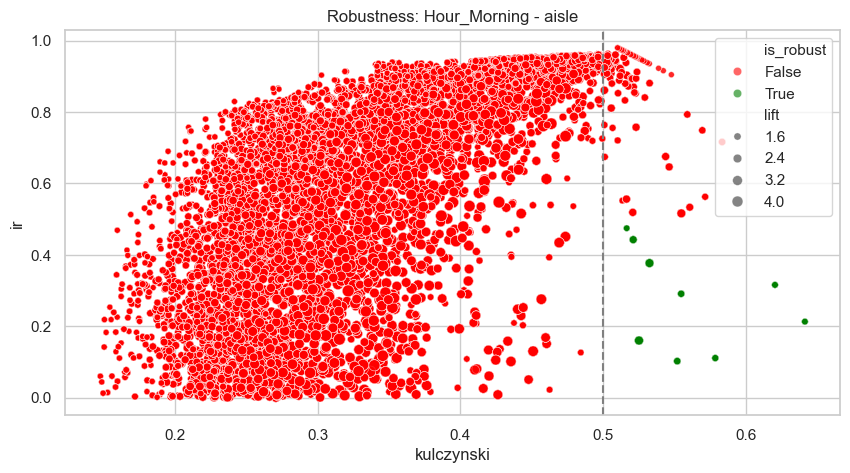

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
41956,"packaged vegetables fruits, fresh vegetables","Large_Basket, Hour_Morning, fresh fruits",2.625876,0.525056,0.160266
41948,"packaged vegetables fruits, fresh vegetables, ...","Large_Basket, fresh fruits",2.625876,0.525056,0.160266
41931,"packaged vegetables fruits, fresh vegetables","fresh fruits, Large_Basket",2.625876,0.525056,0.160266
41957,"Large_Basket, fresh fruits","packaged vegetables fruits, fresh vegetables, ...",2.625876,0.525056,0.160266
41949,"Large_Basket, Hour_Morning, fresh fruits","packaged vegetables fruits, fresh vegetables",2.625876,0.525056,0.160266
41930,"fresh fruits, Large_Basket","packaged vegetables fruits, fresh vegetables",2.625876,0.525056,0.160266
41961,"fresh vegetables, Large_Basket","packaged vegetables fruits, Hour_Morning, fres...",2.516594,0.532423,0.377018
41953,"packaged vegetables fruits, fresh fruits","fresh vegetables, Hour_Morning, Large_Basket",2.516594,0.532423,0.377018
41952,"fresh vegetables, Hour_Morning, Large_Basket","packaged vegetables fruits, fresh fruits",2.516594,0.532423,0.377018
41944,"packaged vegetables fruits, Hour_Morning, fres...","fresh vegetables, Large_Basket",2.516594,0.532423,0.377018


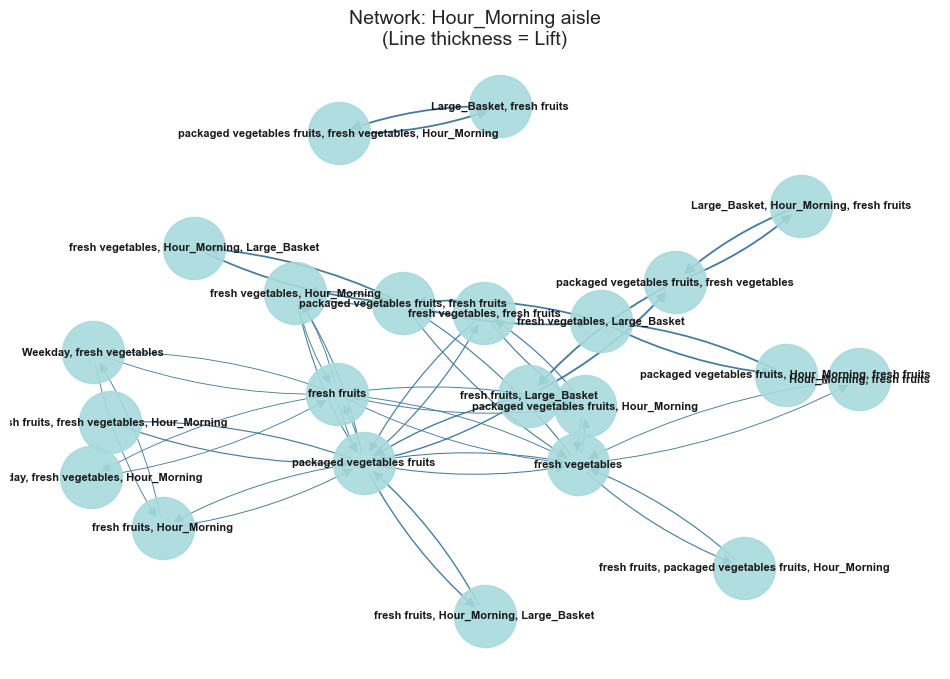

## Hour_Afternoon - AISLE Analysis

Found: 48586 | Unique: 27462 | Robust: 54


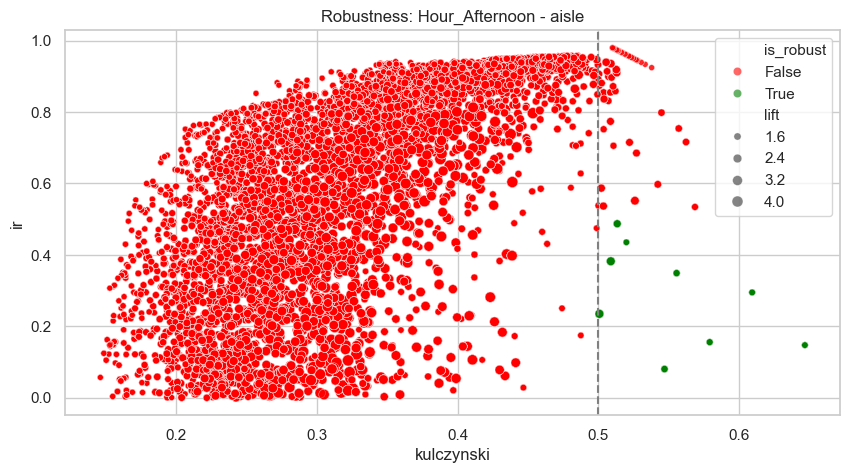

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
15723,"packaged vegetables fruits, fresh vegetables","Large_Basket, fresh fruits, Hour_Afternoon",2.528121,0.500763,0.234959
15699,"packaged vegetables fruits, fresh vegetables","fresh fruits, Large_Basket",2.528121,0.500763,0.234959
15716,"packaged vegetables fruits, fresh vegetables, ...","Large_Basket, fresh fruits",2.528121,0.500763,0.234959
15698,"fresh fruits, Large_Basket","packaged vegetables fruits, fresh vegetables",2.528121,0.500763,0.234959
15725,"Large_Basket, fresh fruits","packaged vegetables fruits, fresh vegetables, ...",2.528121,0.500763,0.234959
15718,"Large_Basket, fresh fruits, Hour_Afternoon","packaged vegetables fruits, fresh vegetables",2.528121,0.500763,0.234959
15700,"packaged vegetables fruits, fresh fruits","fresh vegetables, Large_Basket",2.464023,0.508863,0.382204
15697,"fresh vegetables, Large_Basket","packaged vegetables fruits, fresh fruits",2.464023,0.508863,0.382204
15728,"fresh vegetables, Large_Basket","packaged vegetables fruits, fresh fruits, Hour...",2.464023,0.508863,0.382204
15713,"packaged vegetables fruits, fresh fruits, Hour...","fresh vegetables, Large_Basket",2.464023,0.508863,0.382204


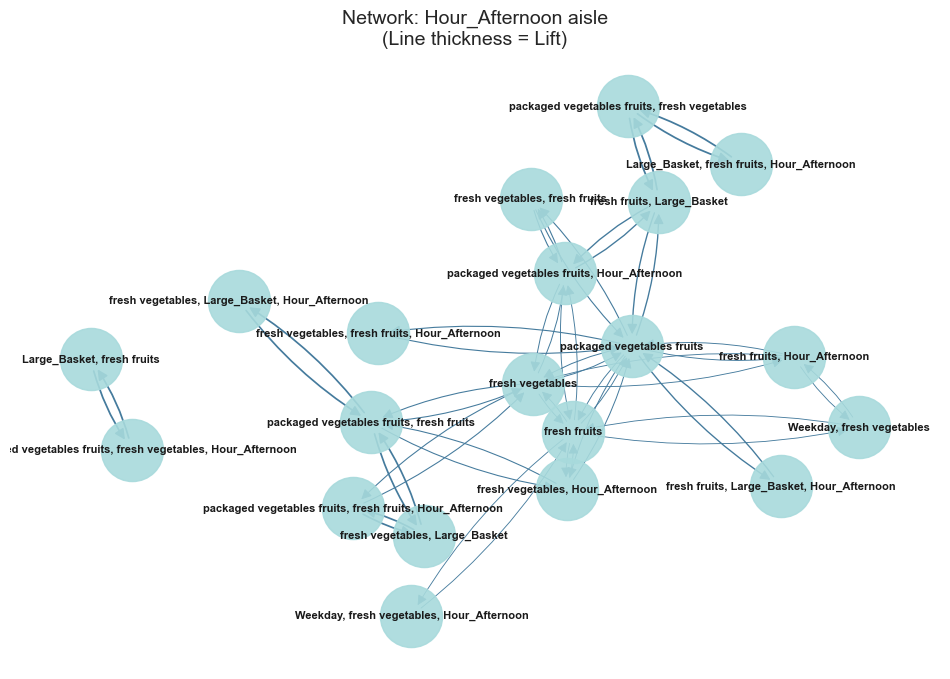

## Hour_Evening - AISLE Analysis

Found: 55976 | Unique: 31868 | Robust: 60


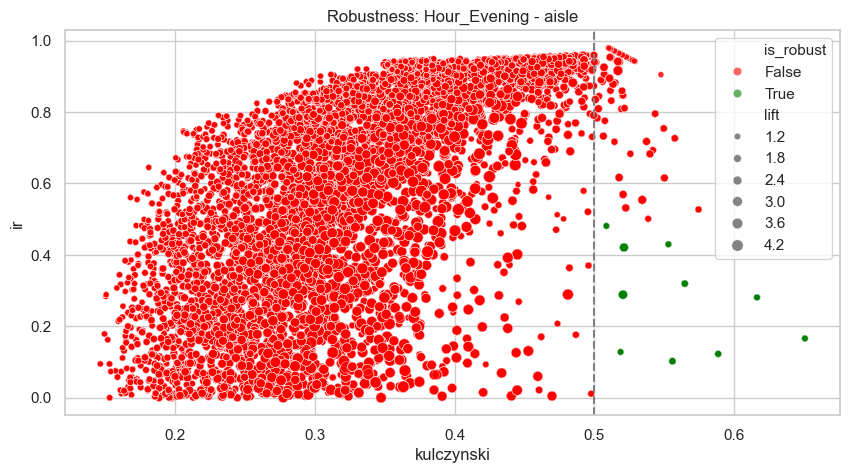

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
22677,"packaged vegetables fruits, fresh vegetables","fresh fruits, Large_Basket",2.642909,0.520550,0.288591
22676,"fresh fruits, Large_Basket","packaged vegetables fruits, fresh vegetables",2.642909,0.520550,0.288591
22706,"Large_Basket, fresh fruits","packaged vegetables fruits, fresh vegetables, ...",2.642909,0.520550,0.288591
22702,"packaged vegetables fruits, fresh vegetables","Large_Basket, Hour_Evening, fresh fruits",2.642909,0.520550,0.288591
22695,"Large_Basket, Hour_Evening, fresh fruits","packaged vegetables fruits, fresh vegetables",2.642909,0.520550,0.288591
22691,"packaged vegetables fruits, fresh vegetables, ...","Large_Basket, fresh fruits",2.642909,0.520550,0.288591
22700,"packaged vegetables fruits, fresh fruits","fresh vegetables, Hour_Evening, Large_Basket",2.492097,0.521281,0.420726
22689,"packaged vegetables fruits, Hour_Evening, fres...","fresh vegetables, Large_Basket",2.492097,0.521281,0.420726
22678,"packaged vegetables fruits, fresh fruits","fresh vegetables, Large_Basket",2.492097,0.521281,0.420726
22675,"fresh vegetables, Large_Basket","packaged vegetables fruits, fresh fruits",2.492097,0.521281,0.420726


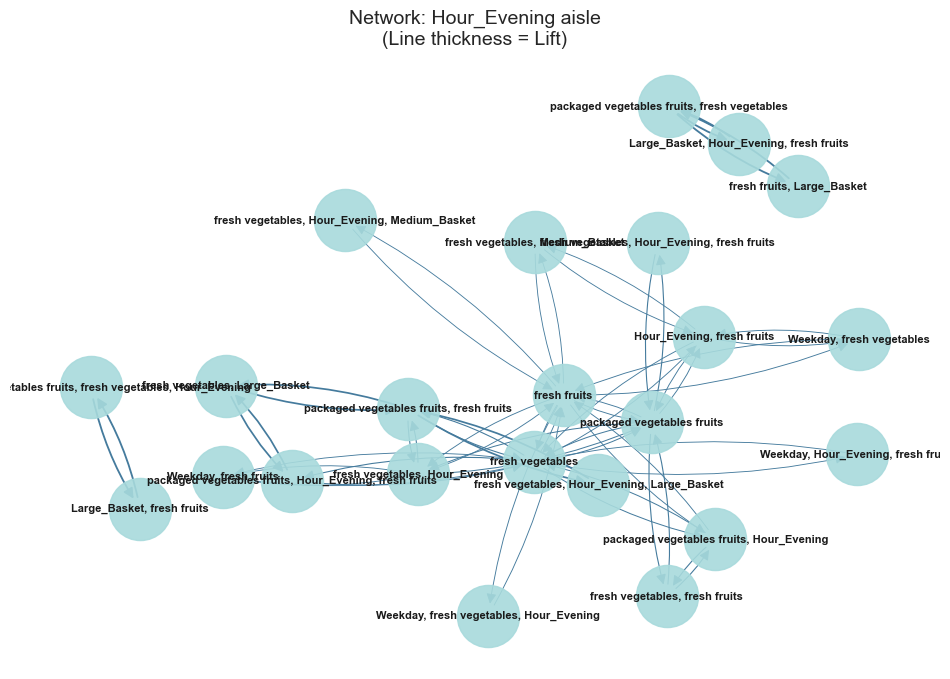

## Hour_Night - AISLE Analysis

Found: 45894 | Unique: 28712 | Robust: 42


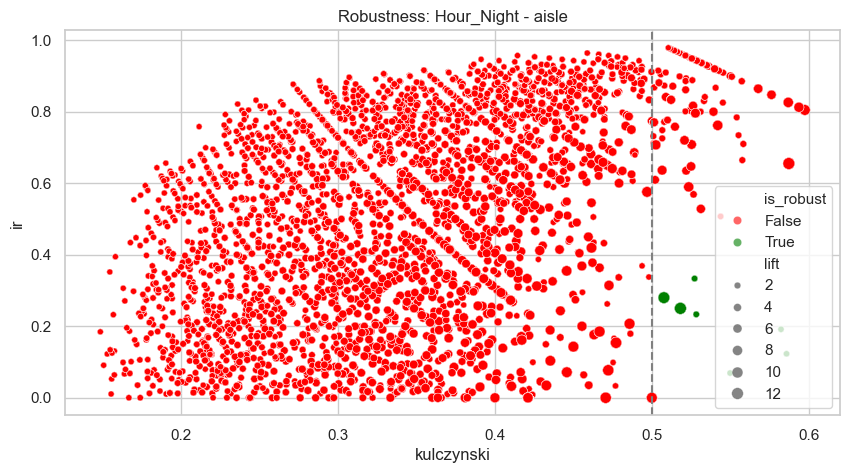

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
28897,"Hour_Night, crackers, Large_Basket","packaged cheese, bread, fresh fruits",12.307692,0.518219,0.250000
28922,"crackers, Large_Basket","Hour_Night, bread, packaged cheese, fresh fruits",12.307692,0.518219,0.250000
28831,"crackers, Large_Basket","packaged cheese, bread, fresh fruits",12.307692,0.518219,0.250000
28814,"packaged cheese, bread, fresh fruits","crackers, Large_Basket",12.307692,0.518219,0.250000
28875,"Hour_Night, bread, packaged cheese, fresh fruits","crackers, Large_Basket",12.307692,0.518219,0.250000
28900,"packaged cheese, bread, fresh fruits","Hour_Night, crackers, Large_Basket",12.307692,0.518219,0.250000
29489,"fresh vegetables, crackers","Hour_Night, bread, packaged cheese, fresh fruits",11.692308,0.507692,0.280000
29379,"packaged cheese, bread, fresh fruits","fresh vegetables, crackers",11.692308,0.507692,0.280000
29398,"fresh vegetables, crackers","packaged cheese, bread, fresh fruits",11.692308,0.507692,0.280000
29440,"Hour_Night, bread, packaged cheese, fresh fruits","fresh vegetables, crackers",11.692308,0.507692,0.280000


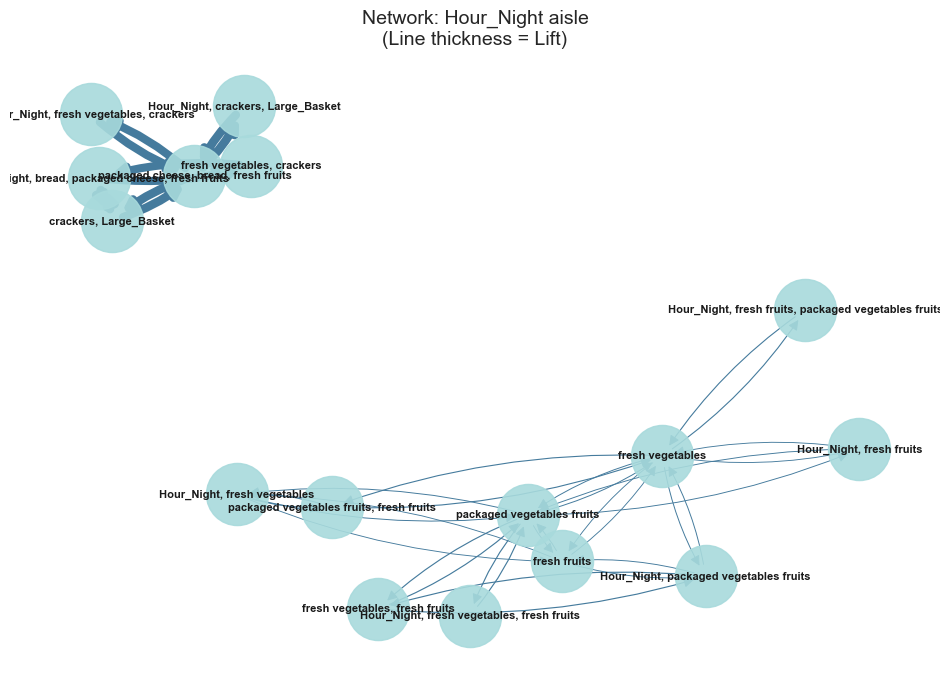

In [65]:
for bin_name in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
    df_subset = df_merged[df_merged['hour_bin'] == bin_name]
    
    rules_store[bin_name]['aisle'] = run_level_pipeline(
        df_subset, 
        level='aisle', 
        sup=0.02, 
        mapping=aisle_to_dept, 
        prev_rules=rules_store[bin_name]['department'],
        dim_name=bin_name
    )

## Hour_Morning - PRODUCT_NAME Analysis

Found: 7726 | Unique: 1676 | Robust: 6


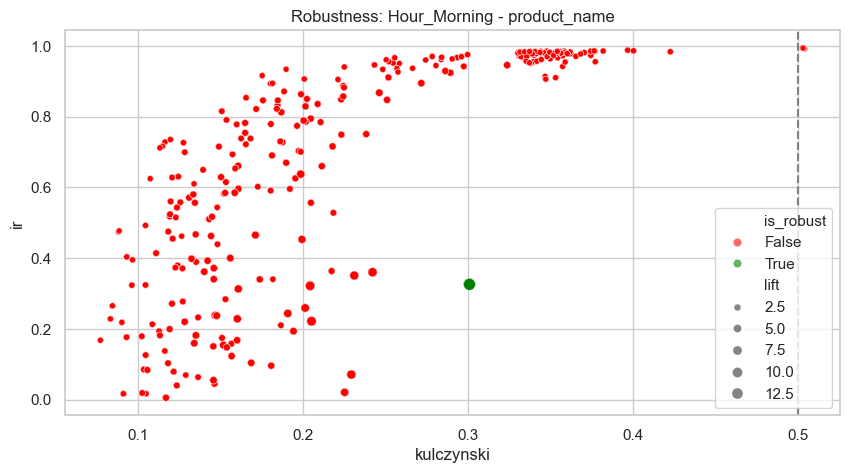

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
7093,Sparkling Water Grapefruit,Lime Sparkling Water,14.850938,0.300895,0.326087
7116,"Hour_Morning, Sparkling Water Grapefruit",Lime Sparkling Water,14.850938,0.300895,0.326087
7119,Sparkling Water Grapefruit,"Lime Sparkling Water, Hour_Morning",14.850938,0.300895,0.326087
7092,Lime Sparkling Water,Sparkling Water Grapefruit,14.850938,0.300895,0.326087
7114,"Lime Sparkling Water, Hour_Morning",Sparkling Water Grapefruit,14.850938,0.300895,0.326087
7117,Lime Sparkling Water,"Hour_Morning, Sparkling Water Grapefruit",14.850938,0.300895,0.326087


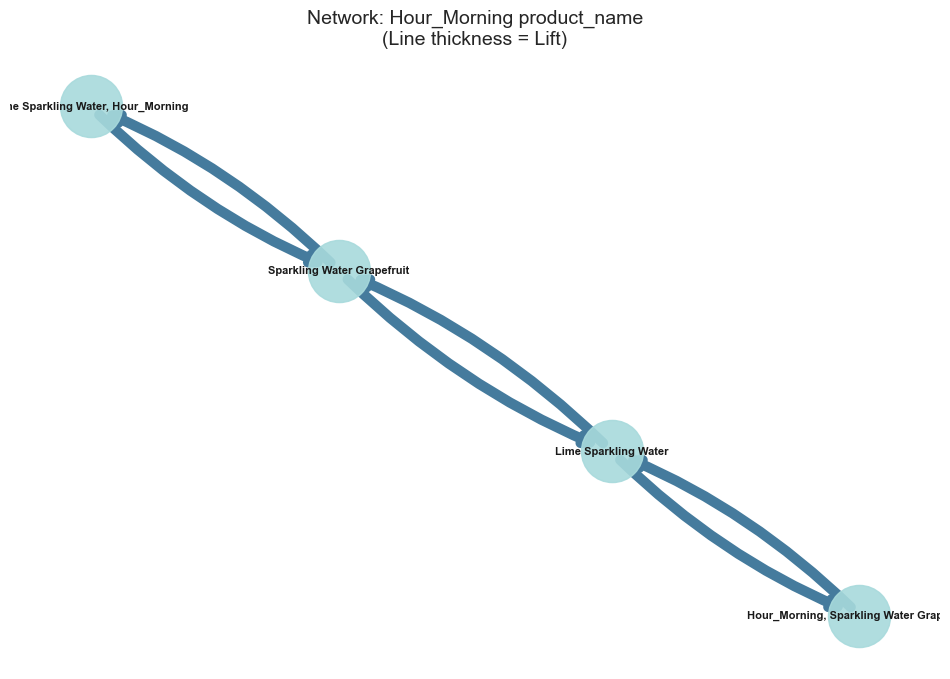

## Hour_Afternoon - PRODUCT_NAME Analysis

Found: 6362 | Unique: 1154 | Robust: 0


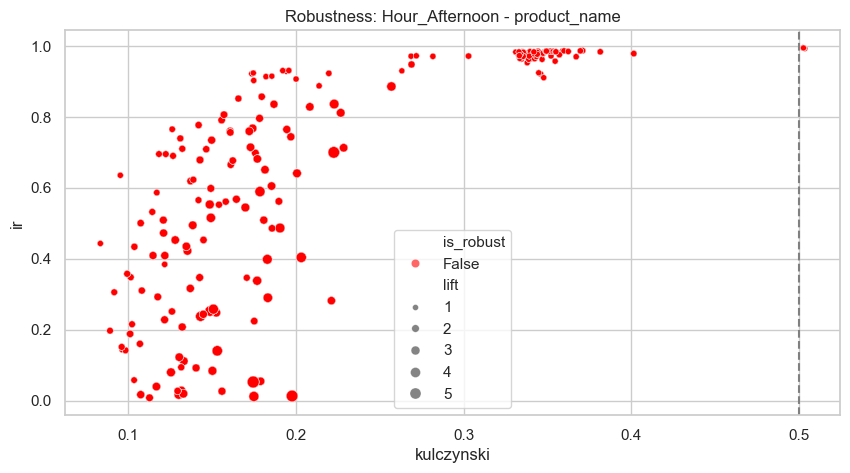

## Hour_Evening - PRODUCT_NAME Analysis

Found: 7482 | Unique: 1496 | Robust: 0


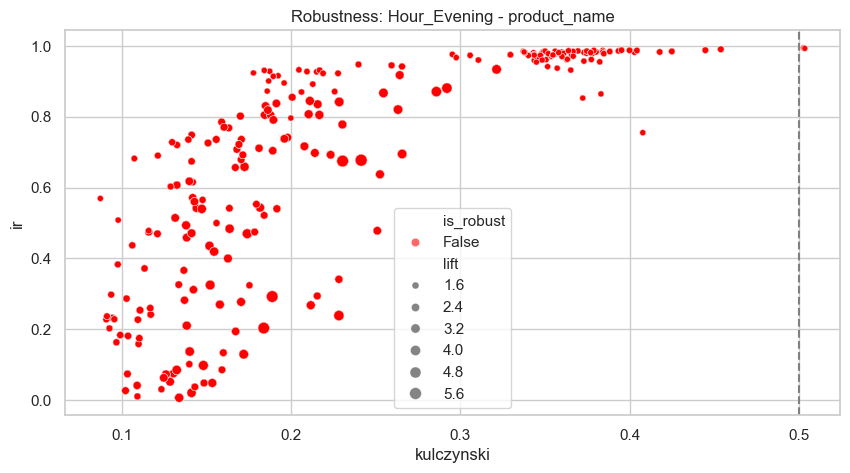

## Hour_Night - PRODUCT_NAME Analysis

Found: 79564 | Unique: 45184 | Robust: 26058


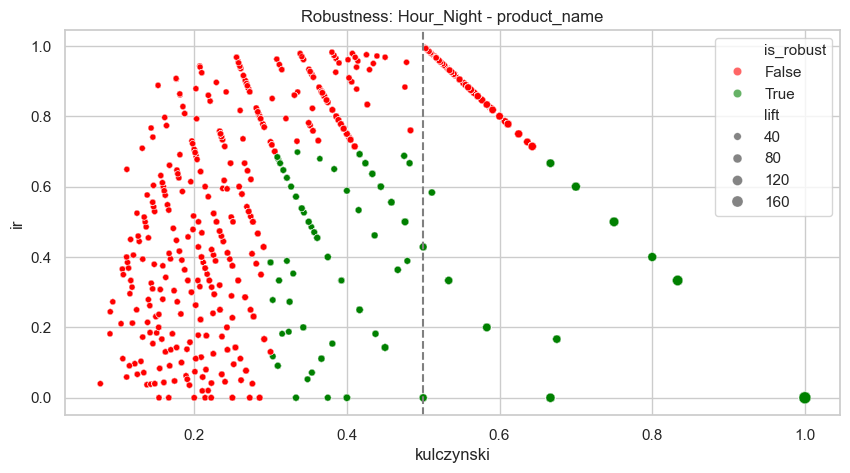

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
64075,"Classic Green Tea, Hour_Night, Weekend, Vitami...","Honey & Maple Turkey Breast, Salted Caramel Gr...",190.0,1.0,0.0
68630,"Weekend, Medium_Basket, Chicken & Maple Breakf...","Revive Zero Vitamin Water, Vitamin Water Zero ...",190.0,1.0,0.0
68627,"Chicken & Maple Breakfast Sausage, Medium_Bask...","Revive Zero Vitamin Water, Weekend",190.0,1.0,0.0
68625,"Weekend, Revive Zero Vitamin Water, Medium_Basket","Chicken & Maple Breakfast Sausage, Vitamin Wat...",190.0,1.0,0.0
68621,"Revive Zero Vitamin Water, Medium_Basket, Vita...","Weekend, Chicken & Maple Breakfast Sausage",190.0,1.0,0.0
68620,"Weekend, Chicken & Maple Breakfast Sausage, Me...",Revive Zero Vitamin Water,190.0,1.0,0.0
68612,Revive Zero Vitamin Water,"Hour_Night, Medium_Basket, Salted Caramel Gree...",190.0,1.0,0.0
68609,"Medium_Basket, Salted Caramel Greek Nonfat Yogurt","Hour_Night, Revive Zero Vitamin Water, Chicken...",190.0,1.0,0.0
68608,"Salted Caramel Greek Nonfat Yogurt, Chicken & ...","Hour_Night, Revive Zero Vitamin Water, Medium_...",190.0,1.0,0.0
68607,"Revive Zero Vitamin Water, Medium_Basket","Hour_Night, Salted Caramel Greek Nonfat Yogurt...",190.0,1.0,0.0


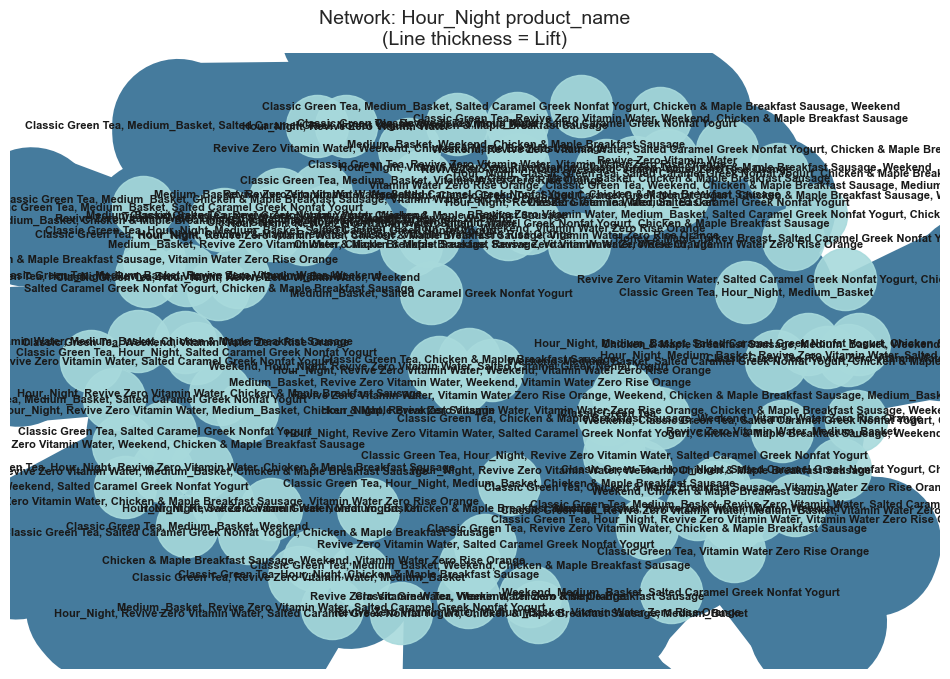

In [66]:
for bin_name in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
    df_subset = df_merged[df_merged['hour_bin'] == bin_name]
    
    rules_store[bin_name]['product_name'] = run_level_pipeline(
        df_subset, 
        level='product_name', 
        sup=0.005, 
        mapping=prod_to_aisle, 
        prev_rules=rules_store[bin_name]['aisle'],
        dim_name=bin_name
    )

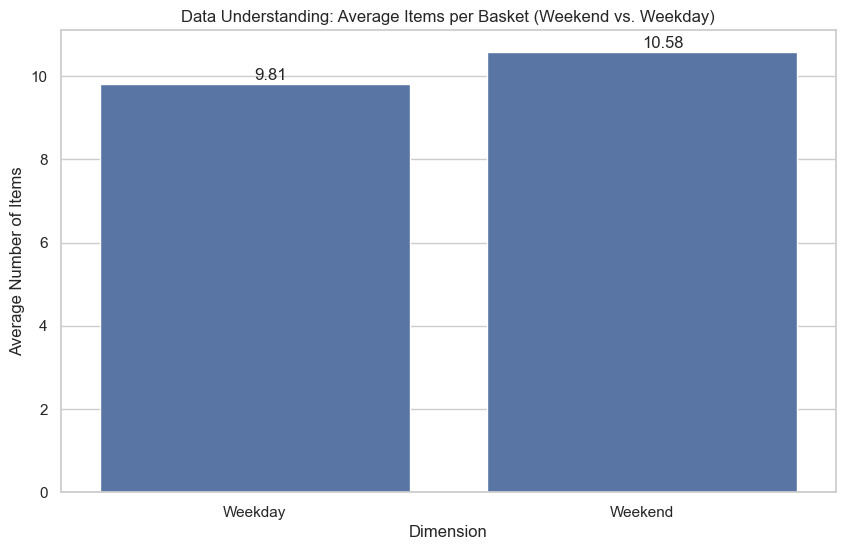

Weekend baskets are larger than Weekday baskets on average


In [67]:
plt.figure(figsize=(10, 6))
basket_stats = df_merged.groupby(['day_type', 'order_id']).size().reset_index(name='items')
avg_items = basket_stats.groupby('day_type')['items'].mean()

sns.barplot(x=avg_items.index, y=avg_items.values)
plt.title('Data Understanding: Average Items per Basket (Weekend vs. Weekday)')
plt.ylabel('Average Number of Items')
plt.xlabel('Dimension')
for i, v in enumerate(avg_items.values): plt.text(i, v + 0.1, f"{v:.2f}")
plt.show()
print(f"{avg_items.idxmax()} baskets are larger than {avg_items.idxmin()} baskets on average")

In [68]:
prod_rules = rules_store['Weekend']['product_name']
conflicting_rules = prod_rules[(prod_rules['lift'] > 2) & (prod_rules['kulczynski'] < 0.4)]
display("Rules where Lift > 2 but Kulczynski < 0.4")
if not conflicting_rules.empty: display(conflicting_rules[['ant_str', 'cons_str', 'lift', 'kulczynski', 'ir']].head(10))

'Rules where Lift > 2 but Kulczynski < 0.4'

,ant_str,cons_str,lift,kulczynski,ir
48,Extra Virgin Olive Oil,Large_Basket,2.218896,0.256076,0.892138
49,Large_Basket,Extra Virgin Olive Oil,2.218896,0.256076,0.892138
59,"Weekend, Large_Basket",Extra Virgin Olive Oil,2.218896,0.256076,0.892138
60,"Extra Virgin Olive Oil, Weekend",Large_Basket,2.218896,0.256076,0.892138
61,Large_Basket,"Extra Virgin Olive Oil, Weekend",2.218896,0.256076,0.892138
62,Extra Virgin Olive Oil,"Weekend, Large_Basket",2.218896,0.256076,0.892138
218,Asparagus,Large_Basket,2.183770,0.260735,0.840025
219,Large_Basket,Asparagus,2.183770,0.260735,0.840025
237,"Weekend, Large_Basket",Asparagus,2.183770,0.260735,0.840025
238,"Asparagus, Weekend",Large_Basket,2.183770,0.260735,0.840025
